<a href="https://colab.research.google.com/github/Andi97-knou/DataAnalysis/blob/knou/%EB%A7%88%EC%A7%80%EB%A7%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache –fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,143 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and dire

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

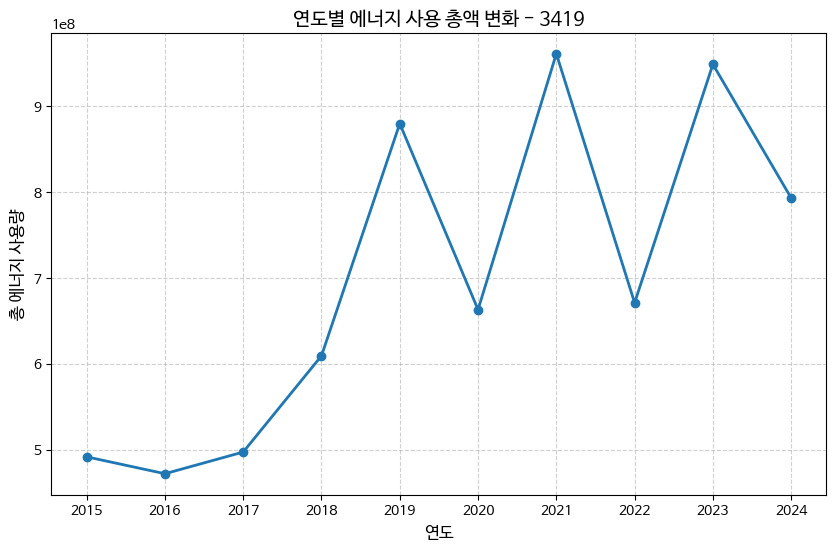

In [ ]:
import matplotlib.pyplot as plt
import requests
import time
import pandas as pd

full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

# 전체 데이터를 저장할 리스트
all_data = []

for year in range(2015, 2025):
    for month in range(1, 13):
        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.3)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

           # if not rows:
           #   print(f"{year}년 {month}월: 데이터 없음")
           #   continue

            # 개인 데이터만 필터링
            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))

            if indiv_rows:
           #     print(f"{year}년 {month}월 개인 데이터 수집 완료")
                 all_data.extend(indiv_rows)
           # else:
           #     print(f"{year}년 {month}월 개인 데이터 없음")

        else:
            print(f"{year}년 {month}월 API 호출 실패: {response.status_code}")


df = pd.DataFrame(all_data)

df = df[["YEAR", "MON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]]

for col in ["EUS", "GUS", "WUS", "HUS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def get_season(month):
    month = int(month)
    if month in [3, 4, 5]:
        return "봄"
    elif month in [6, 7, 8]:
        return "여름"
    elif month in [9, 10, 11]:
        return "가을"
    else:
        return "겨울"

# 계절 컬럼 추가
df["SEASON"] = df["MON"].astype(int).apply(get_season)

# ✅ 컬럼 순서 정리 (MON 포함, DATE 제거)
df = df[["YEAR", "MON", "SEASON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]]

# 숫자 지수 표기 없애기
pd.set_option('display.float_format', '{:,.2f}'.format)

#print(df)

# 총 사용량 컬럼 추가
df["TOTAL_USE"] = df["EUS"] + df["GUS"] + df["WUS"] + df["HUS"]

# 연도별 총합 계산
yearly_total = df.groupby("YEAR")["TOTAL_USE"].sum().reset_index()

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 선 그래프
plt.plot(yearly_total["YEAR"], yearly_total["TOTAL_USE"], marker="o", linewidth=2)

# 제목 (학번 뒷 4자리 넣기)
plt.title("연도별 에너지 사용 총액 변화 - 3419", fontsize=14)

# 축 이름
plt.xlabel("연도", fontsize=12)
plt.ylabel("총 에너지 사용량", fontsize=12)

# 눈금, 격자 추가
plt.grid(True, linestyle="--", alpha=0.6)

# 그래프 저장
plt.savefig("total_energy_3419.png", dpi=300, bbox_inches="tight")

# 화면에 출력
plt.show()



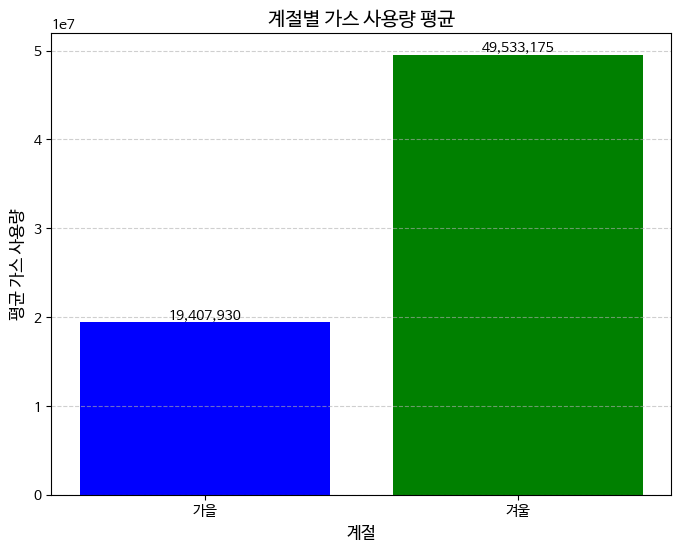

In [ ]:
import matplotlib.pyplot as plt
import requests
import time
import pandas as pd

full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

# 전체 데이터를 저장할 리스트
all_data = []

for year in range(2015, 2025):
    for month in range(1, 13):
        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.3)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

           # if not rows:
           #   print(f"{year}년 {month}월: 데이터 없음")
           #   continue

            # 개인 데이터만 필터링
            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))

            if indiv_rows:
           #     print(f"{year}년 {month}월 개인 데이터 수집 완료")
                 all_data.extend(indiv_rows)
           # else:
           #     print(f"{year}년 {month}월 개인 데이터 없음")

        else:
            print(f"{year}년 {month}월 API 호출 실패: {response.status_code}")


df = pd.DataFrame(all_data)

df = df[["YEAR", "MON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]]

for col in ["EUS", "GUS", "WUS", "HUS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def get_season(month):
    month = int(month)
    if month in [3, 4, 5]:
        return "봄"
    elif month in [6, 7, 8]:
        return "여름"
    elif month in [9, 10, 11]:
        return "가을"
    else:
        return "겨울"


df["SEASON"] = df["MON"].apply(get_season)

season_gas = df.groupby("SEASON")["GUS"].mean().reset_index()


plt.figure(figsize=(8, 6))
bars = plt.bar(season_gas["SEASON"], season_gas["GUS"], color=["blue", "green", "#2ecc71", "#9b59b6"])


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:,.0f}", ha="center", va="bottom", fontsize=10, color="black")


plt.title("계절별 가스 사용량 평균", fontsize=14)
plt.xlabel("계절", fontsize=12)
plt.ylabel("평균 가스 사용량", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

